In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
import pandas as pd

# Nota la 'r' al inicio
PATH = r"C:\Users\Brian OAQ\Desktop\OAQ\2026\12. Manuscrito de un artículo Modelo predictivo de nubosidad para observaciones astronómicas\OAQ-AstroForecast\data\raw\ambient_weather\meteorologia_2026.csv"

df = pd.read_csv(PATH)
print(df.shape)
df.head()

(61697, 8)


,station_mac,fecha_utc,temp_f,humidity,wind_speed_mph,uv,solar_radiation,rain_daily_in
0,F4:CF:A2:E2:BC:AD,2026-01-01 00:00:00,60.8,68.0,0.0,0.0,0.0,0.0
1,F4:CF:A2:E2:BC:AD,2026-01-01 00:05:00,60.8,69.0,0.2,0.0,0.0,0.0
2,F4:CF:A2:E2:BC:AD,2026-01-01 00:10:00,60.6,71.0,1.8,0.0,0.0,0.0
3,F4:CF:A2:E2:BC:AD,2026-01-01 00:15:00,60.4,72.0,0.7,0.0,0.0,0.0
4,F4:CF:A2:E2:BC:AD,2026-01-01 00:20:00,60.3,73.0,0.0,0.0,0.0,0.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61697 entries, 0 to 61696
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   station_mac      61697 non-null  object 
 1   fecha_utc        61697 non-null  object 
 2   temp_f           61581 non-null  float64
 3   humidity         61581 non-null  float64
 4   wind_speed_mph   61581 non-null  float64
 5   uv               61578 non-null  float64
 6   solar_radiation  61578 non-null  float64
 7   rain_daily_in    61697 non-null  float64
dtypes: float64(6), object(2)
memory usage: 3.8+ MB


In [6]:
df.columns.tolist()

['station_mac',
 'fecha_utc',
 'temp_f',
 'humidity',
 'wind_speed_mph',
 'uv',
 'solar_radiation',
 'rain_daily_in']

In [8]:
df["fecha_utc"] = pd.to_datetime(df["fecha_utc"])

print(df["fecha_utc"].min())
print(df["fecha_utc"].max())

2026-01-01 00:00:00
2026-04-29 21:00:00


In [8]:
df["station_mac"].value_counts()

station_mac
F4:CF:A2:E2:C0:8B    32077
F4:CF:A2:E2:BC:AD    29620
Name: count, dtype: int64

In [9]:
missing = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      * 100
)

missing

solar_radiation    0.192878
uv                 0.192878
humidity           0.188016
temp_f             0.188016
wind_speed_mph     0.188016
fecha_utc          0.000000
station_mac        0.000000
rain_daily_in      0.000000
dtype: float64

In [10]:
duplicates = df.duplicated().sum()

print(f"Duplicados: {duplicates}")

Duplicados: 0


In [11]:
for station in df["station_mac"].unique():

    tmp = (
        df[df["station_mac"] == station]
        .sort_values("fecha_utc")
    )

    delta = (
        tmp["fecha_utc"]
        .diff()
        .dt.total_seconds()
        .dropna()
    )

    print("\n")
    print(station)
    print(delta.value_counts().head())



F4:CF:A2:E2:BC:AD
fecha_utc
300.0    29393
240.0       61
360.0       56
600.0       28
900.0       17
Name: count, dtype: int64


F4:CF:A2:E2:C0:8B
fecha_utc
300.0    31939
240.0       41
360.0       39
600.0       16
900.0        7
Name: count, dtype: int64


In [12]:
summary = (
    df.groupby("station_mac")
      .agg({
          "temp_f":["min","max","mean"],
          "humidity":["min","max","mean"],
          "wind_speed_mph":["min","max","mean"],
          "solar_radiation":["min","max","mean"]
      })
)

summary

temp_f                  humidity                   \
                     min   max       mean      min   max       mean   
station_mac                                                           
F4:CF:A2:E2:BC:AD   44.8  78.4  57.691343     24.0  99.0  84.142717   
F4:CF:A2:E2:C0:8B   47.8  74.7  57.197613     22.0  99.0  81.862497   

                  wind_speed_mph                 solar_radiation           \
                             min   max      mean             min      max   
station_mac                                                                 
F4:CF:A2:E2:BC:AD            0.0   8.7  0.331916             0.0  2358.15   
F4:CF:A2:E2:C0:8B            0.0  18.3  2.434768             0.0  1390.72   

                               
                         mean  
station_mac                    
F4:CF:A2:E2:BC:AD  134.604710  
F4:CF:A2:E2:C0:8B  146.116426

In [13]:
summary_count = (
    df.groupby("station_mac")
      .count()
)

summary_count

,fecha_utc,temp_f,humidity,wind_speed_mph,uv,solar_radiation,rain_daily_in
station_mac,,,,,,,
F4:CF:A2:E2:BC:AD,29620,29618,29618,29618,29618,29618,29620
F4:CF:A2:E2:C0:8B,32077,31963,31963,31963,31960,31960,32077


In [14]:
# UTC -> Quito

df["fecha_utc"] = pd.to_datetime(df["fecha_utc"])

df["fecha_local"] = (
    df["fecha_utc"]
    .dt.tz_localize("UTC")
    .dt.tz_convert("America/Guayaquil")
)

df["hora_local"] = df["fecha_local"].dt.hour

df[["fecha_utc", "fecha_local", "hora_local"]].head()

,fecha_utc,fecha_local,hora_local
0,2026-01-01 00:00:00,2025-12-31 19:00:00-05:00,19
1,2026-01-01 00:05:00,2025-12-31 19:05:00-05:00,19
2,2026-01-01 00:10:00,2025-12-31 19:10:00-05:00,19
3,2026-01-01 00:15:00,2025-12-31 19:15:00-05:00,19
4,2026-01-01 00:20:00,2025-12-31 19:20:00-05:00,19


In [15]:
df.groupby("station_mac")["hora_local"].agg(["min","max"])

,min,max
station_mac,,
F4:CF:A2:E2:BC:AD,0,23
F4:CF:A2:E2:C0:8B,0,23


In [16]:
variables = [
    "temp_f",
    "humidity",
    "wind_speed_mph",
    "solar_radiation"
]

hourly = (
    df.groupby(
        ["station_mac", "hora_local"]
    )[variables]
    .mean()
)

hourly

temp_f   humidity  wind_speed_mph  \
station_mac       hora_local                                         
F4:CF:A2:E2:BC:AD 0           53.198693  95.108660        0.020997   
                  1           52.731454  95.413399        0.033497   
                  2           52.271872  95.493868        0.026329   
                  3           51.874632  95.653028        0.013175   
                  4           51.567239  95.705882        0.021895   
                  5           51.322059  95.954248        0.018627   
                  6           51.212337  95.834967        0.017484   
                  7           52.682651  93.522913        0.062029   
                  8           55.836812  86.423948        0.220307   
                  9           60.112914  77.580307        0.468684   
                  10          64.273445  69.242424        0.721770   
                  11          66.816905  64.905556        0.935873   
                  12          67.732508  62.486422        1.053674   
                  13          67.592759  62.651649        0.919952   
                  14          66.392931  64.584591        0.838284   
                  15          64.709020  68.170196        0.777647   
                  16          62.334863  73.690016        0.630676   
                  17          59.841503  80.139706        0.438317   
                  18          57.495837  86.243265        0.255837   
                  19          55.972123  90.009724        0.142869   
                  20          55.064421  91.955629        0.101890   
                  21          54.483252  93.066993        0.069690   
                  22          54.014052  94.024510        0.051879   
                  23          53.597547  94.807032        0.032461   
F4:CF:A2:E2:C0:8B 0           53.599625  92.230480        1.224775   
                  1           53.194140  92.260706        1.409917   
                  2           52.821772  91.912913        1.369294   
                  3           52.504054  91.766517        1.203829   
                  4           52.217358  91.948679        1.254415   
                  5           51.946536  92.173946        1.263931   
                  6           51.922348  91.859848        1.279015   
                  7           53.355766  88.347496        1.707511   
                  8           56.209084  81.521772        2.135886   
                  9           59.184140  75.258377        2.516158   
                  10          61.552427  69.676624        3.023674   
                  11          63.524053  65.904974        3.765924   
                  12          64.747494  63.350785        4.202244   
                  13          65.008561  62.897417        4.362952   
                  14          64.380935  64.648368        4.223887   
                  15          63.237658  67.642058        4.186875   
                  16          61.483620  72.354525        4.195812   
                  17          59.533634  77.758258        3.547147   
                  18          57.431742  83.336364        2.813939   
                  19          56.065434  86.901887        2.310642   
                  20          55.249048  88.985529        1.848134   
                  21          54.726964  90.262840        1.597356   
                  22          54.288363  91.270270        1.457508   
                  23          53.932273  91.996212        1.386364   

                              solar_radiation  
station_mac       hora_local                   
F4:CF:A2:E2:BC:AD 0                  0.000000  
                  1                  0.000000  
                  2                  0.000000  
                  3                  0.000000  
                  4                  0.000000  
                  5                  0.000000  
                  6                  7.048391  
                  7                 51.129337  
                  8                131.708366  
    

In [17]:
hourly.loc["F4:CF:A2:E2:BC:AD"]

,temp_f,humidity,wind_speed_mph,solar_radiation
hora_local,,,,
0,53.198693,95.108660,0.020997,0.000000
1,52.731454,95.413399,0.033497,0.000000
2,52.271872,95.493868,0.026329,0.000000
3,51.874632,95.653028,0.013175,0.000000
4,51.567239,95.705882,0.021895,0.000000
5,51.322059,95.954248,0.018627,0.000000
6,51.212337,95.834967,0.017484,7.048391
7,52.682651,93.522913,0.062029,51.129337
8,55.836812,86.423948,0.220307,131.708366


In [18]:
hourly_compare = (
    df.groupby(
        ["station_mac", "hora_local"]
    )[["temp_f","humidity","wind_speed_mph"]]
    .mean()
    .reset_index()
)

hourly_compare.head()

,station_mac,hora_local,temp_f,humidity,wind_speed_mph
0,F4:CF:A2:E2:BC:AD,0,53.198693,95.108660,0.020997
1,F4:CF:A2:E2:BC:AD,1,52.731454,95.413399,0.033497
2,F4:CF:A2:E2:BC:AD,2,52.271872,95.493868,0.026329
3,F4:CF:A2:E2:BC:AD,3,51.874632,95.653028,0.013175
4,F4:CF:A2:E2:BC:AD,4,51.567239,95.705882,0.021895


In [19]:
roof = "F4:CF:A2:E2:C0:8B"
garden = "F4:CF:A2:E2:BC:AD"

roof_hourly = (
    hourly_compare[
        hourly_compare["station_mac"] == roof
    ]
    .set_index("hora_local")
)

garden_hourly = (
    hourly_compare[
        hourly_compare["station_mac"] == garden
    ]
    .set_index("hora_local")
)

comparison = pd.DataFrame({
    "temp_diff": roof_hourly["temp_f"] - garden_hourly["temp_f"],
    "humidity_diff": roof_hourly["humidity"] - garden_hourly["humidity"],
    "wind_diff": roof_hourly["wind_speed_mph"] - garden_hourly["wind_speed_mph"]
})

comparison

,temp_diff,humidity_diff,wind_diff
hora_local,,,
0,0.400932,-2.878180,1.203778
1,0.462685,-3.152692,1.376421
2,0.549899,-3.580955,1.342966
3,0.629422,-3.886511,1.190654
4,0.650120,-3.757203,1.232520
5,0.624477,-3.780303,1.245303
6,0.710012,-3.975119,1.261531
7,0.673115,-5.175417,1.645482
8,0.372272,-4.902176,1.915578


In [20]:
night = df[
    (df["hora_local"] >= 18) |
    (df["hora_local"] <= 6)
]

night.groupby("station_mac")[
    ["temp_f","humidity","wind_speed_mph"]
].describe()

temp_f                                                     \
                     count       mean       std   min   25%   50%   75%   max   
station_mac                                                                     
F4:CF:A2:E2:BC:AD  15912.0  53.447970  2.558696  44.8  52.0  53.2  54.9  65.7   
F4:CF:A2:E2:C0:8B  17234.0  53.835465  2.299435  47.8  52.3  53.4  55.0  65.7   

                  humidity                                                     \
                     count       mean       std   min   25%   50%   75%   max   
station_mac                                                                     
F4:CF:A2:E2:BC:AD  15912.0  93.787645  5.761531  56.0  93.0  95.0  98.0  99.0   
F4:CF:A2:E2:C0:8B  17234.0  90.536556  6.722567  54.0  88.0  93.0  95.0  99.0   

                  wind_speed_mph                                               
                           count      mean       std  min  25%  50%  75%  max  
station_mac                                                                    
F4:CF:A2:E2:BC:AD        15912.0  0.062104  0.267283  0.0  0.0  0.0  0.0  3.8  
F4:CF:A2:E2:C0:8B        17234.0  1.569757  1.407163  0.0  0.2  1.3  2.2  9.8

In [21]:
df.groupby("station_mac")["rain_daily_in"].describe()

,count,mean,std,min,25%,50%,75%,max
station_mac,,,,,,,,
F4:CF:A2:E2:BC:AD,29620.0,0.107523,0.235011,0.0,0.0,0.0,0.102,1.799
F4:CF:A2:E2:C0:8B,32077.0,0.102582,0.231769,0.0,0.0,0.0,0.083,1.748


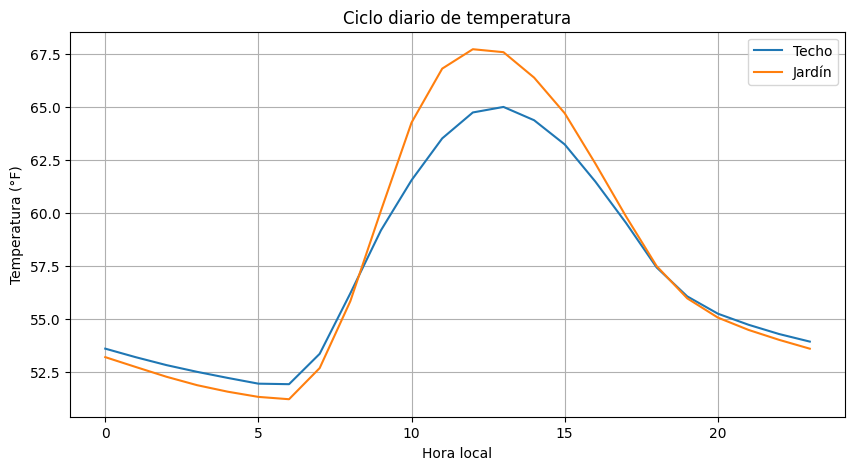

In [22]:
import matplotlib.pyplot as plt

roof = "F4:CF:A2:E2:C0:8B"
garden = "F4:CF:A2:E2:BC:AD"

roof_hourly = (
    df[df["station_mac"] == roof]
    .groupby("hora_local")["temp_f"]
    .mean()
)

garden_hourly = (
    df[df["station_mac"] == garden]
    .groupby("hora_local")["temp_f"]
    .mean()
)

plt.figure(figsize=(10,5))
plt.plot(roof_hourly.index, roof_hourly.values, label="Techo")
plt.plot(garden_hourly.index, garden_hourly.values, label="Jardín")

plt.xlabel("Hora local")
plt.ylabel("Temperatura (°F)")
plt.title("Ciclo diario de temperatura")
plt.grid(True)
plt.legend()

plt.show()

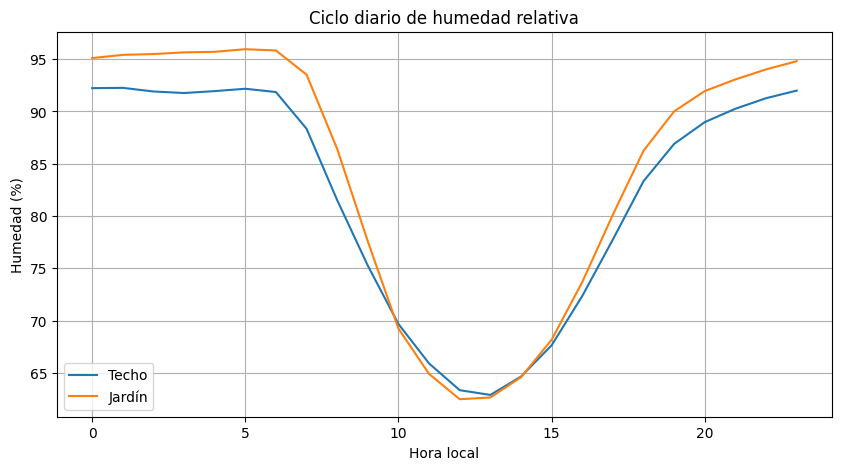

In [23]:
plt.figure(figsize=(10,5))

roof_hourly = (
    df[df["station_mac"] == roof]
    .groupby("hora_local")["humidity"]
    .mean()
)

garden_hourly = (
    df[df["station_mac"] == garden]
    .groupby("hora_local")["humidity"]
    .mean()
)

plt.plot(roof_hourly.index, roof_hourly.values, label="Techo")
plt.plot(garden_hourly.index, garden_hourly.values, label="Jardín")

plt.xlabel("Hora local")
plt.ylabel("Humedad (%)")
plt.title("Ciclo diario de humedad relativa")
plt.grid(True)
plt.legend()

plt.show()

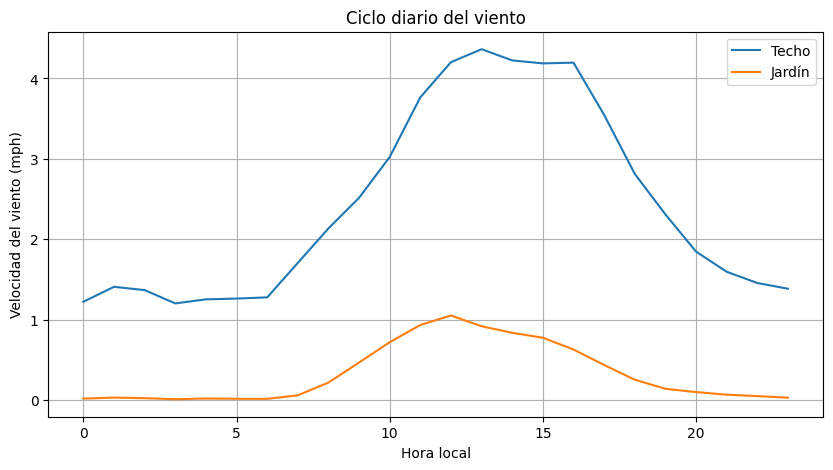

In [24]:
plt.figure(figsize=(10,5))

roof_hourly = (
    df[df["station_mac"] == roof]
    .groupby("hora_local")["wind_speed_mph"]
    .mean()
)

garden_hourly = (
    df[df["station_mac"] == garden]
    .groupby("hora_local")["wind_speed_mph"]
    .mean()
)

plt.plot(roof_hourly.index, roof_hourly.values, label="Techo")
plt.plot(garden_hourly.index, garden_hourly.values, label="Jardín")

plt.xlabel("Hora local")
plt.ylabel("Velocidad del viento (mph)")
plt.title("Ciclo diario del viento")
plt.grid(True)
plt.legend()

plt.show()

In [12]:
df["fecha_local"] = (
    df["fecha_utc"]
      .dt.tz_localize("UTC")
      .dt.tz_convert("America/Guayaquil")
)